# 05 — LangGraph Multi-Agent Pipeline

**EarningsLens | Notebook 05**

---

## Overview

This notebook walks through the **EarningsLens multi-agent pipeline**, built on [LangGraph](https://github.com/langchain-ai/langgraph) — a framework for stateful, graph-structured LLM applications.

### The 4-Agent Architecture

```
Transcript Text
      │
      ▼
┌─────────────┐
│  EXTRACTOR  │  ← Pulls forward-looking guidance targets from transcript
│   Agent 1   │    Primary: LLM extractor | Fallback: spaCy baseline
└──────┬──────┘
       │  extracted_targets, spacy_baseline_targets
       ▼
┌─────────────┐
│ COMPARATOR  │  ← Retrieves historical targets from ChromaDB vector store
│   Agent 2   │    Classifies each target as maintained/rephrased/dropped
└──────┬──────┘
       │  continuity_results, historical_targets
       ▼
┌─────────────┐
│ CLASSIFIER  │  ← Categorises dropped targets (financial vs non-financial,
│   Agent 3   │    persistent vs ephemeral), computes Moving Targets score
└──────┬──────┘
       │  classification_results (risk_score ∈ [0,1])
       ▼
┌─────────────┐
│  REPORTER   │  ← Synthesises structured risk report with investment flag
│   Agent 4   │    Output: HIGH / MEDIUM / LOW risk + recommendation
└─────────────┘
```

### Why Multi-Agent Decomposition?

A single monolithic LLM prompt asking "extract targets, compare to history, classify risk, write a report" suffers from:
1. **Context window pressure** — historical targets from ChromaDB may not fit alongside extraction instructions
2. **Task interference** — extraction quality degrades when the LLM must simultaneously maintain classification logic
3. **Debuggability** — a single black-box output is hard to trace; with 4 agents we can inspect each node's output
4. **Fallback granularity** — the spaCy fallback only needs to activate at the extractor; downstream agents are unaffected

Each agent is a pure function `node(state) -> state`, making them independently testable and replaceable.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1: Imports, environment setup, and sys.path configuration
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import json
import time
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Any

import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

# ── Path setup ───────────────────────────────────────────────────────────────
# Navigate up from notebooks/ to the project root so `src` is importable
# PROJECT_ROOT = Path(os.getcwd()).parent
PROJECT_ROOT = Path(r"C:/Users/Serena/OneDrive - University of Illinois - Urbana\Desktop/Columbia/5293/project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python path includes project root: {str(PROJECT_ROOT) in sys.path}")

# ── Environment variables ────────────────────────────────────────────────────
# Load .env if present (for OPENAI_API_KEY, CHROMA_PATH, etc.)
try:
    from dotenv import load_dotenv
    env_path = PROJECT_ROOT /"src"/ '.env'
    if env_path.exists():
        load_dotenv(env_path)
        print(f"Loaded .env from {env_path}")
    else:
        print("No .env file found — using environment variables directly")
except ImportError:
    print("python-dotenv not installed — skipping .env load")

# Check for API key
OPENAI_KEY_SET = bool(os.getenv('OPENAI_API_KEY'))
print(f"OPENAI_API_KEY set: {OPENAI_KEY_SET}")

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.WARNING,           # suppress INFO-level chatter from agents
    format='%(name)s | %(levelname)s | %(message)s'
)
print("Setup complete.")

Project root: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project
Python path includes project root: True
Loaded .env from C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\src\.env
OPENAI_API_KEY set: True
Setup complete.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2: Verify core dependencies are installed
# ─────────────────────────────────────────────────────────────────────────────
import importlib
from importlib.metadata import version
REQUIRED_PACKAGES = [
    ('langgraph', 'langgraph'),
    ('langchain', 'langchain'),
    ('langchain_openai', 'langchain-openai'),
    ('chromadb', 'chromadb'),
    ('spacy', 'spacy'),
    ('openai', 'openai'),
]

missing = []
for module, pip_name in REQUIRED_PACKAGES:
    spec = importlib.util.find_spec(module)
    status = '✓' if spec is not None else '✗  MISSING'
    if spec is None:
        missing.append(pip_name)
    print(f"  {status}  {module}")

if missing:
    print(f"\nInstall missing packages with:")
    print(f"  pip install {' '.join(missing)}")
else:
    print("\nAll required packages are installed.")

# Check langgraph version — API changed significantly at 0.2.x
try:
    import langgraph
    # print(f"\nlanggraph version: {langgraph.__version__}")
    print(version("langgraph"))
except Exception:
    print("Could not determine langgraph version")

  ✓  langgraph
  ✓  langchain
  ✓  langchain_openai
  ✓  chromadb
  ✓  spacy
  ✓  openai

All required packages are installed.
1.1.10


---
## Section 1: Understanding the PipelineState Schema

The `PipelineState` is a **TypedDict** — a typed Python dictionary — that serves as the shared memory passing through all four agents. LangGraph merges updates returned by each node into the running state automatically.

### Key design decisions:
- `total=False` — every field is optional, so a partial state update from one agent is valid
- Lists (`extracted_targets`, `errors`) accumulate across agents; dicts are replaced
- The `errors` field allows non-fatal failures: if the LLM extractor fails, the error is logged and spaCy takes over — the pipeline continues rather than crashing
- `spacy_baseline_targets` is **always populated** even when the LLM extractor succeeds, enabling downstream comparison of both signals

### State flow summary:
| Field | Populated by | Read by |
|---|---|---|
| `transcript_text` | caller | extractor |
| `extracted_targets` | extractor | comparator, classifier |
| `spacy_baseline_targets` | extractor | reporter, notebook |
| `historical_targets` | comparator | classifier |
| `continuity_results` | comparator | classifier, reporter |
| `classification_results` | classifier | reporter |
| `report` | reporter | caller |
| `errors` | any agent | caller |

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3: Import and introspect PipelineState
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.state import PipelineState, make_initial_state

# Create a sample initial state to see the schema
sample_state = make_initial_state(
    transcript_text="Sample earnings call text for demonstration purposes.",
    company_id="AAPL",
    ticker="AAPL",
    fiscal_quarter="2023Q3"
)

print("PipelineState fields and initial values:")
print("=" * 70)
for key, value in sample_state.items():
    type_name = type(value).__name__
    repr_str = repr(value)[:80]
    if len(repr(value)) > 80:
        repr_str += '...'
    print(f"  {key:<30} {type_name:<10}  {repr_str}")

print(f"\nTotal fields: {len(sample_state)}")

PipelineState fields and initial values:
  transcript_text                str         'Sample earnings call text for demonstration purposes.'
  transcript_id                  NoneType    None
  company_id                     str         'AAPL'
  firm_id                        str         'AAPL'
  ticker                         str         'AAPL'
  fiscal_quarter                 str         '2023Q3'
  quarter                        str         '2023Q3'
  extracted_targets              list        []
  spacy_baseline_targets         list        []
  extraction_metadata            dict        {}
  historical_targets             list        []
  matched_targets                list        []
  continuity_results             dict        {'maintained': [], 'rephrased': [], 'dropped': [], 'new': [], 'discontinued': []...
  classified_revision            dict        {}
  classification_results         dict        {}
  mt_score                       float       0.0
  direction                   

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4: Inspect PipelineState type hints (from the TypedDict definition)
# ─────────────────────────────────────────────────────────────────────────────
import typing

# TypedDict stores annotations in __annotations__
annotations = PipelineState.__annotations__

print("PipelineState type annotations:")
print("=" * 50)
for field, hint in annotations.items():
    print(f"  {field:<35} {str(hint)}")

print(f"\ntotal=False means all fields are Optional (no KeyError if missing)")

PipelineState type annotations:
  transcript_text                     ForwardRef('str', module='src.agents.state')
  transcript_id                       ForwardRef('str | None', module='src.agents.state')
  company_id                          ForwardRef('str', module='src.agents.state')
  firm_id                             ForwardRef('str | None', module='src.agents.state')
  ticker                              ForwardRef('str', module='src.agents.state')
  fiscal_quarter                      ForwardRef('str', module='src.agents.state')
  quarter                             ForwardRef('str | None', module='src.agents.state')
  extracted_targets                   ForwardRef('list[dict[str, Any]]', module='src.agents.state')
  spacy_baseline_targets              ForwardRef('list[dict[str, Any]]', module='src.agents.state')
  extraction_metadata                 ForwardRef('dict[str, Any]', module='src.agents.state')
  historical_targets                  ForwardRef('list[dict[str, Any]]',

---
## Section 2: Testing Individual Agents

Before assembling the full LangGraph pipeline, let's test each agent node independently. Each node is a function `node(state: PipelineState) -> PipelineState` — we can call them directly in sequence.

This is useful for:
- **Debugging** a specific stage without running the full pipeline
- **Unit testing** individual agent logic
- **Understanding** what each agent adds to the state

We'll use a real transcript from the transcripts parquet file.

In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Cell 5: Load a real transcript segment for testing
# # ─────────────────────────────────────────────────────────────────────────────
# # TRANSCRIPTS_PATH = PROJECT_ROOT / 'data' / 'raw' / 'ciq_transcripts.parquet'

# # transcripts_df = pd.read_parquet(TRANSCRIPTS_PATH)
# # print(f"Loaded {len(transcripts_df)} transcripts")
# # print(f"Columns: {list(transcripts_df.columns)}")
# # print(f"Date range: {transcripts_df['date'].min()} → {transcripts_df['date'].max()}" 
# #       if 'date' in transcripts_df.columns else "(no date column)")
# # transcripts_df.head(3)

# # ─────────────────────────────────────────────────────────────────────────────
# # Cell 5: Load a small CIQ transcript sample for testing
# # ─────────────────────────────────────────────────────────────────────────────
# import pyarrow.parquet as pq

# TRANSCRIPTS_PATH = PROJECT_ROOT / "data" / "raw" / "ciq_transcripts.parquet"
# MAX_ROWS = 1000

# pf = pq.ParquetFile(TRANSCRIPTS_PATH)

# print(f"Parquet row groups: {pf.num_row_groups}")
# print(f"Total columns: {len(pf.schema.names)}")
# print(f"Columns: {pf.schema.names}")

# # Load row groups until we have at most MAX_ROWS
# chunks = []
# rows_loaded = 0

# for rg in range(pf.num_row_groups):
#     table = pf.read_row_group(rg)
#     df_chunk = table.to_pandas()
#     chunks.append(df_chunk)
#     rows_loaded += len(df_chunk)

#     if rows_loaded >= MAX_ROWS:
#         break

# transcripts_df = pd.concat(chunks, ignore_index=True).head(MAX_ROWS)

# print(f"\nLoaded sample: {len(transcripts_df):,} rows")
# print(f"Columns: {list(transcripts_df.columns)}")

# date_col = next((c for c in transcripts_df.columns if c.lower() in {"date", "call_date", "transcript_date"}), None)

# if date_col:
#     print(f"Date range in sample: {transcripts_df[date_col].min()} → {transcripts_df[date_col].max()}")
# else:
#     print("(no date column found)")

# transcripts_df.head(3)

Parquet row groups: 104
Total columns: 12
Columns: ['companyid', 'companyname', 'transcriptid', 'keydevid', 'event_date', 'event_type', 'call_date', 'transcriptcomponentid', 'componenttypeid', 'transcriptpersonid', 'componentorder', 'componenttext']

Loaded sample: 1,000 rows
Columns: ['companyid', 'companyname', 'transcriptid', 'keydevid', 'event_date', 'event_type', 'call_date', 'transcriptcomponentid', 'componenttypeid', 'transcriptpersonid', 'componentorder', 'componenttext']
Date range in sample: 2010-01-04 → 2010-03-31


,companyid,companyname,transcriptid,keydevid,event_date,event_type,call_date,transcriptcomponentid,componenttypeid,transcriptpersonid,componentorder,componenttext
0,27060.0,"Cornell Companies, Inc.",53710.0,97187270.0,2010-02-25,Earnings Calls,2010-03-16,4063089,3,120716,26,So the contribution from those two facilities ...
1,391070.0,Universal Display Corporation,53728.0,99077808.0,2010-03-15,Earnings Calls,2010-03-16,4064051,4,130874,29,"In the 10-K , we included an extension through..."
2,391070.0,Universal Display Corporation,53728.0,99077808.0,2010-03-15,Earnings Calls,2010-03-16,4064055,3,19747,33,Can you give us an update on the progress of y...


In [23]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Cell 5: Load a real transcript segment for testing
# # ─────────────────────────────────────────────────────────────────────────────
# # TRANSCRIPTS_PATH = PROJECT_ROOT / 'data' / 'raw' / 'ciq_transcripts.parquet'

# # transcripts_df = pd.read_parquet(TRANSCRIPTS_PATH)
# # print(f"Loaded {len(transcripts_df)} transcripts")
# # print(f"Columns: {list(transcripts_df.columns)}")
# # print(f"Date range: {transcripts_df['date'].min()} → {transcripts_df['date'].max()}" 
# #       if 'date' in transcripts_df.columns else "(no date column)")
# # transcripts_df.head(3)

# # ─────────────────────────────────────────────────────────────────────────────
# # Cell 5: Load a small CIQ transcript sample for testing
# # ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import pyarrow.parquet as pq
from tqdm.auto import tqdm

components_path = PROJECT_ROOT / "data" / "raw" / "ciq_transcripts.parquet"

MAX_TRANSCRIPTS = 1000

if components_path.exists():
    pf = pq.ParquetFile(components_path)
    nrows = pf.metadata.num_rows
    colnames = set(pf.schema_arrow.names)

    wanted_cols = [
        "transcriptid",
        "companyname",
        "componenttypeid",
        "componentorder",
        "componenttext",
    ]

    for c in [
        "companyid",
        "transcriptpersonname",
        "transcriptpersonid",
        "call_date",
        "event_date",
        "transcriptcreationdate",
        "fiscalyear",
        "fiscalquarter",
    ]:
        if c in colnames and c not in wanted_cols:
            wanted_cols.append(c)

    usecols = [c for c in wanted_cols if c in colnames]

    print(f"Parquet file found: {components_path}")
    print(f"Total rows: {nrows:,}")
    print(f"Row groups: {pf.num_row_groups:,}")
    print(f"Columns loaded: {usecols}")

    # Need companyid + fiscal quarter info to prioritize valid MT pairs
    date_col = None
    for c in ["call_date", "event_date", "transcriptcreationdate"]:
        if c in colnames:
            date_col = c
            break

    if "companyid" not in colnames:
        raise ValueError("companyid column is required to prioritize company-quarter pairs.")

    if "fiscalyear" in colnames and "fiscalquarter" in colnames:
        scan_cols = ["transcriptid", "companyid", "fiscalyear", "fiscalquarter"]
        use_existing_fiscal_cols = True
    elif date_col is not None:
        scan_cols = ["transcriptid", "companyid", date_col]
        use_existing_fiscal_cols = False
    else:
        raise ValueError(
            "Need fiscalyear/fiscalquarter or a date column "
            "(call_date/event_date/transcriptcreationdate)."
        )

    # Step 1: scan lightweight metadata
    company_quarter_to_tid = {}
    all_seen_tids = []
    seen_all = set()

    for row_group_i in tqdm(range(pf.num_row_groups), desc="Scanning company-quarter metadata"):
        meta_df = pf.read_row_group(row_group_i, columns=scan_cols).to_pandas()
        meta_df = meta_df.dropna(subset=["transcriptid", "companyid"])

        if use_existing_fiscal_cols:
            meta_df = meta_df.dropna(subset=["fiscalyear", "fiscalquarter"])
            meta_df["_fy"] = meta_df["fiscalyear"].astype(int)
            meta_df["_fq"] = meta_df["fiscalquarter"].astype(int)
        else:
            meta_df[date_col] = pd.to_datetime(meta_df[date_col], errors="coerce")
            meta_df = meta_df.dropna(subset=[date_col])
            meta_df["_fy"] = meta_df[date_col].dt.year.astype(int)
            meta_df["_fq"] = meta_df[date_col].dt.quarter.astype(int)

        meta_df = meta_df.drop_duplicates(subset=["transcriptid"], keep="first")

        for _, row in meta_df.iterrows():
            tid = row["transcriptid"]

            if tid not in seen_all:
                seen_all.add(tid)
                all_seen_tids.append(tid)

            cid = str(row["companyid"])
            fy = int(row["_fy"])
            fq = int(row["_fq"])

            company_quarter_to_tid.setdefault(cid, {})[(fy, fq)] = tid

    # Step 2: select YoY pairs first
    selected_tids_list = []
    selected_set = set()

    for cid, qmap in company_quarter_to_tid.items():
        for (fy, fq), tid in qmap.items():
            lag_key = (fy - 1, fq)

            if lag_key not in qmap:
                continue

            lag_tid = qmap[lag_key]

            for x in [lag_tid, tid]:
                if x not in selected_set:
                    selected_set.add(x)
                    selected_tids_list.append(x)

            if len(selected_tids_list) >= MAX_TRANSCRIPTS:
                break

        if len(selected_tids_list) >= MAX_TRANSCRIPTS:
            break

    print(f"Selected from YoY company-quarter pairs: {len(selected_tids_list):,}")

    # Step 3: if not enough, fill with regular transcripts
    if len(selected_tids_list) < MAX_TRANSCRIPTS:
        for tid in all_seen_tids:
            if tid not in selected_set:
                selected_set.add(tid)
                selected_tids_list.append(tid)

            if len(selected_tids_list) >= MAX_TRANSCRIPTS:
                break

    selected_tids = set(selected_tids_list[:MAX_TRANSCRIPTS])

    print(f"Final selected transcript IDs: {len(selected_tids):,}")

    # Step 4: load selected rows only
    parts = []

    for row_group_i in tqdm(range(pf.num_row_groups), desc="Loading selected transcript rows"):
        batch_df = pf.read_row_group(row_group_i, columns=usecols).to_pandas()
        batch_df = batch_df[batch_df["transcriptid"].isin(selected_tids)]

        if len(batch_df) > 0:
            if "componenttypeid" in batch_df.columns:
                batch_df = batch_df[batch_df["componenttypeid"].isin([2, 3, 4])]

            if len(batch_df) > 0:
                parts.append(batch_df)

        loaded_tids = set(pd.concat(parts)["transcriptid"].unique()) if parts else set()

        if selected_tids.issubset(loaded_tids):
            break

    components_df = (
        pd.concat(parts, ignore_index=True)
        if parts
        else pd.DataFrame(columns=usecols)
    )

    if "transcriptpersonname" not in components_df.columns:
        if "transcriptpersonid" in components_df.columns:
            components_df["transcriptpersonname"] = components_df["transcriptpersonid"].astype(str)
        else:
            components_df["transcriptpersonname"] = ""

    if "fiscalyear" not in components_df.columns or "fiscalquarter" not in components_df.columns:
        if date_col is not None and date_col in components_df.columns:
            components_df[date_col] = pd.to_datetime(components_df[date_col], errors="coerce")
            components_df["fiscalyear"] = components_df[date_col].dt.year
            components_df["fiscalquarter"] = components_df[date_col].dt.quarter

    if "call_date" not in components_df.columns:
        for alt in ["event_date", "transcriptcreationdate"]:
            if alt in components_df.columns:
                components_df["call_date"] = components_df[alt]
                break

    print(f"\nLoaded transcript components: {components_df.shape}")
    print(f"Unique transcripts loaded: {components_df['transcriptid'].nunique():,}")
    print(f"Unique companies loaded: {components_df['companyid'].nunique():,}")
    display(components_df.head(3))

else:
    print(f"Components file not found at {components_path}")

Parquet file found: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\raw\ciq_transcripts.parquet
Total rows: 68,323,879
Row groups: 104
Columns loaded: ['transcriptid', 'companyname', 'componenttypeid', 'componentorder', 'componenttext', 'companyid', 'transcriptpersonid', 'call_date', 'event_date']


Scanning company-quarter metadata: 100%|██████████| 104/104 [01:08<00:00,  1.51it/s]


Selected from YoY company-quarter pairs: 1,001
Final selected transcript IDs: 1,000


Loading selected transcript rows:  98%|█████████▊| 102/104 [01:48<00:02,  1.06s/it]


Loaded transcript components: (51402, 12)
Unique transcripts loaded: 1,000
Unique companies loaded: 32


,transcriptid,companyname,componenttypeid,componentorder,componenttext,companyid,transcriptpersonid,call_date,event_date,transcriptpersonname,fiscalyear,fiscalquarter
0,52541.0,Shenandoah Telecommunications Company,4,51,"Well, Sprint would not sell because we are Spr...",378088.0,61923,2010-03-04,2010-03-04,61923,2010,1
1,53838.0,"FARO Technologies, Inc.",2,4,"Thanks, Keith. So as expected, 2009 was an ext...",365602.0,127190,2010-03-17,2010-02-25,127190,2010,1
2,53838.0,"FARO Technologies, Inc.",3,8,And can we talk a little bit about the gross m...,365602.0,102782,2010-03-17,2010-02-25,102782,2010,1


In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Cell 6: Select a sample transcript and prepare state for node testing
# # ─────────────────────────────────────────────────────────────────────────────
# # Pick the first transcript row for testing
# sample_row = transcripts_df.iloc[0]

# # Determine column names dynamically (they vary by data version)
# text_col  = next((c for c in transcripts_df.columns if 'text' in c.lower() or 'transcript' in c.lower()), transcripts_df.columns[0])
# id_col    = next((c for c in transcripts_df.columns if 'company' in c.lower() or 'cid' in c.lower() or 'companyid' in c.lower()), None)
# tick_col  = next((c for c in transcripts_df.columns if 'ticker' in c.lower()), None)
# yr_col    = next((c for c in transcripts_df.columns if 'year' in c.lower() or 'fiscalyear' in c.lower()), None)
# qtr_col   = next((c for c in transcripts_df.columns if 'quarter' in c.lower() or 'fiscalquarter' in c.lower()), None)

# sample_text = str(sample_row[text_col])[:8000]   # cap at 8k chars for faster testing
# company_id  = str(sample_row[id_col]) if id_col else 'TEST_CO'
# ticker      = str(sample_row[tick_col]) if tick_col else 'TEST'
# year        = str(sample_row[yr_col]) if yr_col else '2023'
# qtr         = str(sample_row[qtr_col]) if qtr_col else '1'
# fiscal_qtr  = f"{year}Q{qtr}"

# print(f"Company ID : {company_id}")
# print(f"Ticker     : {ticker}")
# print(f"Quarter    : {fiscal_qtr}")
# print(f"Text len   : {len(sample_text)} chars")
# print(f"\nFirst 300 chars:")
# print(sample_text[:300])

Company ID : 27060.0
Ticker     : TEST
Quarter    : 2023Q1
Text len   : 7 chars

First 300 chars:
53710.0


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6: Select a KPI-rich transcript sample and prepare state
# ─────────────────────────────────────────────────────────────────────────────

if "text" in components_df.columns:
    text_col = "text"
elif "componenttext" in components_df.columns:
    text_col = "componenttext"
else:
    raise ValueError(f"No text column found. Columns: {list(components_df.columns)}")

id_col = "companyid" if "companyid" in components_df.columns else None
tick_col = "ticker" if "ticker" in components_df.columns else None
yr_col = "fiscalyear" if "fiscalyear" in components_df.columns else None
qtr_col = "fiscalquarter" if "fiscalquarter" in components_df.columns else None

usable_df = components_df[
    components_df[text_col].notna()
    & (components_df[text_col].astype(str).str.len() > 300)
].copy()

# Stronger filter: must contain both forward-looking language and KPI language
forward_terms = r"expect|guidance|outlook|forecast|anticipate|project|target|next year|next quarter|full[- ]year"
kpi_terms = r"revenue|sales|eps|earnings|margin|gross margin|operating margin|ebitda|cash flow|capex|growth|basis points|bps|percent|%|\$|million|billion"

mask = (
    usable_df[text_col].astype(str).str.contains(forward_terms, case=False, regex=True, na=False)
    & usable_df[text_col].astype(str).str.contains(kpi_terms, case=False, regex=True, na=False)
)

candidate_df = usable_df[mask].copy()

if len(candidate_df) == 0:
    print("WARNING: No KPI-rich guidance rows found; falling back to broader guidance rows.")
    candidate_df = usable_df[
        usable_df[text_col].astype(str).str.contains(
            forward_terms + "|" + kpi_terms,
            case=False,
            regex=True,
            na=False,
        )
    ].copy()

if len(candidate_df) == 0:
    raise ValueError("No usable transcript rows found with target-like language.")

# Prefer longer text because it gives the extractor more context
candidate_df["_text_len"] = candidate_df[text_col].astype(str).str.len()
sample_row = candidate_df.sort_values("_text_len", ascending=False).iloc[0]

sample_text = str(sample_row[text_col])[:8000]
company_id = str(sample_row[id_col]) if id_col else "TEST_CO"
ticker = str(sample_row[tick_col]) if tick_col else "TEST"
year = str(int(sample_row[yr_col])) if yr_col and pd.notna(sample_row[yr_col]) else "2023"
qtr = str(int(sample_row[qtr_col])) if qtr_col and pd.notna(sample_row[qtr_col]) else "1"
fiscal_qtr = f"{year}Q{qtr}"

print(f"Candidate rows: {len(candidate_df):,}")
print(f"Text column: {text_col}")
print(f"Company ID : {company_id}")
print(f"Ticker     : {ticker}")
print(f"Quarter    : {fiscal_qtr}")
print(f"Text len   : {len(sample_text)} chars")
print("\nFirst 600 chars:")
print(sample_text[:600])

Candidate rows: 7,863
Text column: componenttext
Company ID : 365602.0
Ticker     : TEST
Quarter    : 2012Q1
Text len   : 8000 chars

First 600 chars:
Let's get started. So good morning everybody. Thanks for joining us today. This is our second investor conference. We did the last one about 18 months ago. 18 months is probably the cycle we runt these on. We like to do it after we've had a couple of product launches each time. So I think that's the right cycle and we've had enough changes over each of the 18-month cycles that it makes sense to do it every 18 instead of once a year or something like that. If you want to argue that point, I am all yours later on in the day.
So thanks for coming in and for those who are listening in on the webca


In [25]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "spacy",
    "download",
    "en_core_web_sm",
])

0

In [8]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded:", nlp.meta["name"])

spaCy model loaded: core_web_sm


In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7: Test the Extractor Agent (Agent 1)
#
# The extractor runs TWO extractors:
#   1. spaCy baseline — fast, rule-based, always runs
#   2. LLM extractor  — GPT-4o-based, may fail gracefully
#
# If the LLM extractor succeeds, `extracted_targets` = LLM output
# and `spacy_baseline_targets` = spaCy output (for comparison).
# If the LLM extractor fails, spaCy results are used as the primary signal.
# ─────────────────────────────────────────────────────────────────────────────
import importlib
import src.agents.extractor_agent as extractor_agent

importlib.reload(extractor_agent)

extractor_node = extractor_agent.extractor_node


# Build initial state
state = make_initial_state(
    transcript_text=sample_text,
    company_id=company_id,
    ticker=ticker,
    fiscal_quarter=fiscal_qtr
)

print("Running Extractor Agent...")
t0 = time.perf_counter()
state = extractor_node(state)
elapsed = time.perf_counter() - t0

print(f"\nExtractor completed in {elapsed:.2f}s")
print(f"Extracted {len(state['extracted_targets'])} LLM targets")
print(f"spaCy baseline found {len(state['spacy_baseline_targets'])} targets")
print(f"Errors logged: {state['errors']}")

print(f"\nFirst 5 extracted targets:")
for i, t in enumerate(state["extracted_targets"][:5]):
    label = t.get("metric_name", "N/A")
    financial = "financial" if t.get("is_financial") else "non-financial"
    direction = t.get("trend_direction", "unknown")
    horizon = t.get("time_horizon", "unknown")
    value = t.get("numerical_value", None)
    unit = t.get("unit", "")

    value_str = f"{value} {unit}" if value is not None else "qualitative"

    print(
        f"  [{i+1}] {label:<45} "
        f"({financial}, {direction}, {horizon}, {value_str})"
    )

Running Extractor Agent...

Extractor completed in 7.32s
Extracted 5 LLM targets
spaCy baseline found 2 targets
Errors logged: []

First 5 extracted targets:
  [1] sales growth                                  (financial, up, forward, 20.0 percent)
  [2] gross margin                                  (financial, up, forward, 60.0 percent)
  [3] operating margin                              (financial, up, forward, 18.0 percent)
  [4] sales target                                  (financial, up, forward, 1000000000.0 dollars)
  [5] EPS                                           (financial, up, historical, 1.39 dollars)


In [52]:
test_text = """
We expect full-year revenue to reach $10 billion, representing 8% growth.
We also expect gross margin to expand 150 basis points next year.
"""

state = make_initial_state(
    transcript_text=test_text,
    company_id="TEST_CO",
    ticker="TEST",
    fiscal_quarter="2023Q3"
)

state = extractor_node(state)

print("Primary targets:", len(state["extracted_targets"]))
print("spaCy targets:", len(state["spacy_baseline_targets"]))
print("Errors:", state["errors"])
print(state["extracted_targets"][:5])

Primary targets: 2
spaCy targets: 2
Errors: []
[{'metric_name': 'full-year revenue', 'raw_text': 'reach $10 billion', 'numerical_value': 10000000000.0, 'trend_direction': 'up', 'unit': 'dollars', 'time_horizon': 'forward', 'is_financial': True, 'confidence': 'high', 'canonical_name': 'full revenue', 'source': 'llm'}, {'metric_name': 'gross margin', 'raw_text': 'expand 150 basis points next year', 'numerical_value': 150.0, 'trend_direction': 'up', 'unit': 'bps', 'time_horizon': 'forward', 'is_financial': True, 'confidence': 'high', 'canonical_name': 'gross margin', 'source': 'llm'}]


In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8: Inspect extractor output in detail
# ─────────────────────────────────────────────────────────────────────────────
# Show the full schema of one extracted target
if state['extracted_targets']:
    print("Sample extracted target (full dict):")
    print(json.dumps(state['extracted_targets'][0], indent=2, default=str))
else:
    print("No LLM targets extracted. Sample spaCy target:")
    if state['spacy_baseline_targets']:
        print(json.dumps(state['spacy_baseline_targets'][0], indent=2, default=str))

# Count target types
all_targets = state['extracted_targets'] or state['spacy_baseline_targets']
fin_count    = sum(1 for t in all_targets if t.get('target_type') == 'financial' or t.get('is_financial'))
nonfin_count = len(all_targets) - fin_count
print(f"\nTarget breakdown:  financial={fin_count}  |  non-financial={nonfin_count}")

Sample extracted target (full dict):
{
  "metric_name": "full-year revenue",
  "raw_text": "reach $10 billion",
  "numerical_value": 10000000000.0,
  "trend_direction": "up",
  "unit": "dollars",
  "time_horizon": "forward",
  "is_financial": true,
  "confidence": "high",
  "canonical_name": "full revenue",
  "source": "llm"
}

Target breakdown:  financial=2  |  non-financial=0


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9: Test the Comparator Agent (Agent 2)
#
# The comparator:
#   1. Retrieves historical targets from ChromaDB for the prior 4 quarters
#   2. Embeds both current and historical targets
#   3. Uses cosine similarity to classify each current target as:
#      - maintained  (similarity > 0.85)
#      - rephrased   (0.60 < similarity < 0.85)
#      - dropped     (similarity < 0.60 to any historical target)
#
# NOTE: This requires prior quarters to be indexed in ChromaDB.
# If ChromaDB is empty, comparator will return all targets as 'dropped'
# (first-quarter companies have no history to compare against).
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.comparator_agent import comparator_node

print("Running Comparator Agent...")
t0 = time.perf_counter()
state = comparator_node(state)
elapsed = time.perf_counter() - t0

cr = state.get('continuity_results', {})
print(f"\nComparator completed in {elapsed:.2f}s")
print(f"Historical targets retrieved: {len(state.get('historical_targets', []))}")
print(f"Continuity results:")
print(f"  maintained : {len(cr.get('maintained', []))}")
print(f"  rephrased  : {len(cr.get('rephrased', []))}")
print(f"  dropped    : {len(cr.get('dropped', []))}")
print(f"Errors logged: {state['errors']}")

Running Comparator Agent...

Comparator completed in 0.00s
Historical targets retrieved: 0
Continuity results:
  maintained : 0
  rephrased  : 0
  dropped    : 2
Errors logged: []


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10: Test the Classifier Agent (Agent 3)
#
# The classifier uses the continuity results to compute the Moving Targets (MT)
# score — the key signal in Cohen & Nguyen (2024).
#
# Classification dimensions:
#   1. Financial vs Non-Financial dropped targets
#      - Financial: revenue, EPS, margins, capex, guidance ranges
#      - Non-Financial: expansion plans, hiring, product launches
#   2. Persistent vs Ephemeral dropped targets
#      - Persistent: same target dropped in 2+ consecutive quarters (more suspicious)
#      - Ephemeral: one-off drop (may be legitimate)
#
# The risk_score ∈ [0,1] is a weighted combination of these ratios.
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.classifier_agent import classifier_node

print("Running Classifier Agent...")
t0 = time.perf_counter()
state = classifier_node(state)
elapsed = time.perf_counter() - t0

cls = state.get('classification_results', {})
print(f"\nClassifier completed in {elapsed:.2f}s")
print(f"\nRisk Score: {cls.get('risk_score', 'N/A'):.4f}")
print(f"Financial drop ratio     : {cls.get('financial_drop_ratio', 0):.4f}")
print(f"Non-financial drop ratio : {cls.get('nonfinancial_drop_ratio', 0):.4f}")
print(f"Persistent drop ratio    : {cls.get('persistent_drop_ratio', 0):.4f}")
print(f"\nDropped financial targets    : {len(cls.get('dropped_financial', []))}")
print(f"Dropped non-financial targets: {len(cls.get('dropped_non_financial', []))}")
print(f"Persistent dropped           : {len(cls.get('persistent_dropped', []))}")
print(f"Ephemeral dropped            : {len(cls.get('ephemeral_dropped', []))}")

Running Classifier Agent...

Classifier completed in 0.00s

Risk Score: 0.6000
Financial drop ratio     : 1.0000
Non-financial drop ratio : 0.0000
Persistent drop ratio    : 0.0000

Dropped financial targets    : 2
Dropped non-financial targets: 0
Persistent dropped           : 0
Ephemeral dropped            : 2


In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11: Test the Reporter Agent (Agent 4)
#
# The reporter synthesises the upstream results into a structured risk report:
#   - risk_flag: HIGH / MEDIUM / LOW (thresholds: >0.6 = HIGH, 0.3-0.6 = MEDIUM)
#   - summary: one-paragraph natural language risk assessment
#   - recommendation: investment implication (e.g. "Consider reducing position")
#   - dropped_targets: table rows for the report
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.reporter_agent import reporter_node

print("Running Reporter Agent...")
t0 = time.perf_counter()
state = reporter_node(state)
elapsed = time.perf_counter() - t0

report = state.get('report', {})
print(f"Reporter completed in {elapsed:.2f}s")
print("\n" + "=" * 60)
print("RISK REPORT")
print("=" * 60)
print(json.dumps(report, indent=2, default=str))

Running Reporter Agent...
Reporter completed in 0.00s

RISK REPORT
{
  "company_id": "TEST_CO",
  "ticker": "TEST",
  "fiscal_quarter": "2023Q3",
  "risk_flag": "LOW",
  "risk_score": 0.0,
  "mt_score": 0.0,
  "direction": "UNKNOWN",
  "summary": "The pipeline extracted 2 primary targets and 2 spaCy baseline targets for TEST 2023Q3. It compared them with 0 historical targets: 0 maintained, 0 rephrased, and 0 dropped. The resulting risk score is 0.000, giving a LOW risk flag. The MT-style score is 0.000, indicating UNKNOWN target momentum.",
  "recommendation": "Low discontinuity risk. No major target deterioration was detected from the available transcript comparison.",
  "counts": {
    "extracted_targets": 2,
    "spacy_baseline_targets": 2,
    "historical_targets": 0,
    "maintained": 0,
    "rephrased": 0,
    "dropped": 0,
    "dropped_financial": 0,
    "dropped_non_financial": 0
  },
  "ratios": {
    "financial_drop_ratio": 0.0,
    "nonfinancial_drop_ratio": 0.0,
    "persis

---
## Section 3: Assembling the Graph

In the individual tests above we called each agent function manually. In production, LangGraph manages the execution flow — maintaining shared state, routing between nodes, and handling errors.

### LangGraph StateGraph concepts:

- **StateGraph(PipelineState)** — a directed graph where each node receives and returns `PipelineState`
- **`add_node(name, fn)`** — registers a node with a callable
- **`add_edge(from, to)`** — defines the execution order
- **`set_entry_point(name)`** — declares which node runs first
- **`compile()`** — returns an invokable `CompiledGraph` object
- **`app.invoke(initial_state)`** — runs the full graph and returns the final state

Our graph is a simple linear chain: `extractor → comparator → classifier → reporter → END`. No branching is needed because the fallback logic is internal to the extractor node.

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12: Show the graph construction code
#
# We read and display the actual graph.py source — this is the canonical
# definition; what you see here is exactly what's used in production.
# ─────────────────────────────────────────────────────────────────────────────
graph_source = (PROJECT_ROOT / 'src' / 'agents' / 'graph.py').read_text()

# Extract just the build_graph function for clarity
start = graph_source.find('def build_graph()')
end   = graph_source.find('\n\n\n', start)
print(graph_source[start:end])

def build_graph():
    """Build and compile the linear LangGraph pipeline.

    Flow:
        extractor â†’ comparator â†’ classifier â†’ reporter â†’ END
    """

    graph = StateGraph(PipelineState)

    graph.add_node("extractor", extractor_node)
    graph.add_node("comparator", comparator_node)
    graph.add_node("classifier", classifier_node)
    graph.add_node("reporter", reporter_node)

    graph.set_entry_point("extractor")

    graph.add_edge("extractor", "comparator")
    graph.add_edge("comparator", "classifier")
    graph.add_edge("classifier", "reporter")
    graph.add_edge("reporter", END)

    return graph.compile()


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 13: Compile the graph and print its structure
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.graph import build_graph, run_pipeline, run_batch, get_compiled_app

print("Compiling LangGraph StateGraph...")
t0 = time.perf_counter()
app = build_graph()
elapsed = time.perf_counter() - t0

print(f"Graph compiled in {elapsed:.3f}s")
print(f"App type: {type(app).__name__}")

# Try to display the graph structure
try:
    # LangGraph ≥ 0.2 supports get_graph()
    graph_repr = app.get_graph()
    print(f"\nGraph nodes: {list(graph_repr.nodes.keys())}")
    print(f"Graph edges:")
    for edge in graph_repr.edges:
        print(f"  {edge.source} → {edge.target}")
except AttributeError:
    # Older versions
    print("\nGraph topology (linear chain):")
    print("  extractor → comparator → classifier → reporter → END")

Compiling LangGraph StateGraph...
Graph compiled in 0.014s
App type: CompiledStateGraph

Graph nodes: ['__start__', 'extractor', 'comparator', 'classifier', 'reporter', '__end__']
Graph edges:
  __start__ → extractor
  classifier → reporter
  comparator → classifier
  extractor → comparator
  reporter → __end__


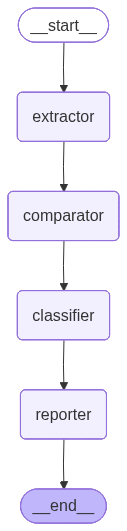

Graph rendered via Mermaid.


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14: Visualise the graph (ASCII fallback)
# ─────────────────────────────────────────────────────────────────────────────
# Try Mermaid/graphviz if available; fall back to ASCII art
try:
    from IPython.display import Image, display
    png_bytes = app.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
    print("Graph rendered via Mermaid.")
except Exception as e:
    print(f"Graph visualisation not available ({e}). Showing ASCII:")
    ascii_graph = """
  ┌──────────────────────────────────────────────────┐
  │         EarningsLens LangGraph Pipeline          │
  └──────────────────────────────────────────────────┘

  [START]
     │
     ▼
  ┌──────────┐    extracted_targets
  │ extractor│─────────────────────────►
  │  (node)  │    spacy_baseline_targets│
  └──────────┘                          │
                                        ▼
                              ┌──────────────┐    continuity_results
                              │  comparator  │─────────────────────►
                              │   (node)     │    historical_targets│
                              └──────────────┘                      │
                                                                     ▼
                                                        ┌────────────────┐
                                                        │  classifier    │
                                                        │   (node)       │
                                                        └───────┬────────┘
                                                                │  classification_results
                                                                ▼
                                                        ┌────────────────┐
                                                        │   reporter     │
                                                        │   (node)       │
                                                        └───────┬────────┘
                                                                │  report
                                                                ▼
                                                             [END]
"""
    print(ascii_graph)

---
## Section 4: End-to-End Pipeline Run

Now we run the full pipeline using `run_pipeline()` — the high-level convenience function that:
1. Creates an initial `PipelineState` via `make_initial_state()`
2. Invokes the compiled LangGraph app
3. Handles exceptions and returns the final state dict

The result is a plain `Dict[str, Any]` with all state fields populated.

In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 15: Run the full end-to-end pipeline on one company-quarter
# ─────────────────────────────────────────────────────────────────────────────
print(f"Running full pipeline for {ticker} {fiscal_qtr}...")
t0 = time.perf_counter()

result = run_pipeline(
    transcript_text=sample_text,
    company_id=company_id,
    ticker=ticker,
    quarter=fiscal_qtr
)

total_time = time.perf_counter() - t0

print(f"\nPipeline completed in {total_time:.2f}s")
print(f"\n{'='*60}")
print("PIPELINE RESULT SUMMARY")
print(f"{'='*60}")
print(f"  Company         : {result.get('company_id')} ({result.get('ticker')})")
print(f"  Quarter         : {result.get('fiscal_quarter')}")
print(f"  Extracted targets (LLM)  : {len(result.get('extracted_targets', []))}")
print(f"  Extracted targets (spaCy): {len(result.get('spacy_baseline_targets', []))}")
print(f"  Historical targets       : {len(result.get('historical_targets', []))}")

cr = result.get('continuity_results', {})
print(f"  Maintained  : {len(cr.get('maintained', []))}")
print(f"  Rephrased   : {len(cr.get('rephrased', []))}")
print(f"  Dropped     : {len(cr.get('dropped', []))}")

cls = result.get('classification_results', {})
print(f"  Risk score  : {cls.get('risk_score', 0):.4f}")

rpt = result.get('report', {})
print(f"  Risk flag   : {rpt.get('risk_flag', 'N/A')}")
print(f"  Errors      : {result.get('errors', [])}")

Running full pipeline for TEST 2012Q1...

Pipeline completed in 4.82s

PIPELINE RESULT SUMMARY
  Company         : 365602.0 (TEST)
  Quarter         : 2012Q1
  Extracted targets (LLM)  : 5
  Extracted targets (spaCy): 2
  Historical targets       : 0
  Maintained  : 0
  Rephrased   : 0
  Dropped     : 5
  Risk score  : 0.6000
  Risk flag   : MEDIUM
  Errors      : []


In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 16: Inspect extracted targets detail
# ─────────────────────────────────────────────────────────────────────────────
targets = result.get('extracted_targets', [])
if targets:
    targets_df = pd.DataFrame(targets)
    print(f"Extracted Targets DataFrame ({len(targets_df)} rows):")
    display_cols = [c for c in ['metric_name', 'target_text', 'target_type', 'is_financial', 'context']
                    if c in targets_df.columns]
    print(targets_df[display_cols].head(10).to_string(index=False))
else:
    print("No LLM targets in result (check errors above).")

Extracted Targets DataFrame (5 rows):
     metric_name  is_financial
    sales growth          True
    gross margin          True
operating margin          True
    sales target          True
             EPS          True


In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 17: Display the final risk report in a nicely formatted way
# ─────────────────────────────────────────────────────────────────────────────
import textwrap

report = result.get('report', {})
risk_flag = report.get('risk_flag', 'N/A')

# Colour coding for terminal display
FLAG_COLOURS = {'HIGH': '\033[91m', 'MEDIUM': '\033[93m', 'LOW': '\033[92m'}
RESET = '\033[0m'
colour = FLAG_COLOURS.get(risk_flag, '')

print("=" * 65)
print(f"  EARNINGSLENS RISK REPORT")
print("=" * 65)
print(f"  Company  : {result.get('ticker', '')} ({result.get('company_id', '')})")
print(f"  Quarter  : {result.get('fiscal_quarter', '')}")
print(f"  Risk Flag: {colour}{risk_flag}{RESET}")
print(f"  Score    : {result.get('classification_results', {}).get('risk_score', 0):.4f}")
print("=" * 65)
print("\nSUMMARY:")
summary = report.get('summary', 'No summary generated.')
for line in textwrap.wrap(summary, width=65):
    print(f"  {line}")

print("\nRECOMMENDATION:")
rec = report.get('recommendation', 'No recommendation generated.')
for line in textwrap.wrap(rec, width=65):
    print(f"  {line}")

if report.get('dropped_targets'):
    print(f"\nDROPPED TARGETS ({len(report['dropped_targets'])}):")
    for dt in report['dropped_targets'][:5]:
        name = dt.get('metric_name', dt.get('target_text', 'N/A'))
        ttype = dt.get('target_type', '?')
        print(f"  • {name} [{ttype}]")

print(f"\n  Generated at: {report.get('generated_at', 'N/A')}")
print("=" * 65)

  EARNINGSLENS RISK REPORT
  Company  : TEST (365602.0)
  Quarter  : 2012Q1
  Risk Flag: MEDIUM
  Score    : 0.6000

SUMMARY:
  The pipeline extracted 5 primary targets and 2 spaCy baseline
  targets for TEST 2012Q1. It compared them with 0 historical
  targets: 0 maintained, 0 rephrased, and 5 dropped. The resulting
  risk score is 0.600, giving a MEDIUM risk flag. The MT-style
  score is -1.000, indicating DOWN target momentum.

RECOMMENDATION:
  Monitor the company closely. Some targets appear revised or
  missing, but the signal is not extreme.

DROPPED TARGETS (5):
  • sales growth [?]
  • gross margin [?]
  • operating margin [?]
  • sales target [?]
  • EPS [?]

  Generated at: 2026-05-02T08:27:58.276037+00:00


---
## Section 5: Batch Processing

`run_batch()` processes multiple company-quarters sequentially, reusing the same compiled LangGraph app for efficiency. It handles per-transcript errors gracefully — a failed transcript returns an error state but does not abort the batch.

In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 18: Prepare a batch of 10 company-quarters
# ─────────────────────────────────────────────────────────────────────────────
sample_transcripts = components_df.head(10)

# Build the batch input list — run_batch expects dicts with specific keys
transcripts_batch = []
for _, row in sample_transcripts.iterrows():
    year_val = str(row[yr_col]) if yr_col and yr_col in row.index else '2023'
    qtr_val  = str(row[qtr_col]) if qtr_col and qtr_col in row.index else '1'
    transcripts_batch.append({
        "transcript_text": str(row[text_col])[:4000],   # truncate for speed
        "company_id"     : str(row[id_col]) if id_col else 'UNKNOWN',
        "ticker"         : str(row[tick_col]) if tick_col else 'UNK',
        "fiscal_quarter" : f"{year_val}Q{qtr_val}",
    })

print(f"Prepared {len(transcripts_batch)} transcripts for batch processing")
print(f"Companies: {[t['ticker'] for t in transcripts_batch]}")

Prepared 10 transcripts for batch processing
Companies: ['UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK', 'UNK']


In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 19: Run batch pipeline
# ─────────────────────────────────────────────────────────────────────────────
print(f"Running batch of {len(transcripts_batch)} transcripts...")
t0 = time.perf_counter()

batch_results = run_batch(transcripts_batch)

total_time = time.perf_counter() - t0
print(f"\nBatch completed: {len(batch_results)} results in {total_time:.1f}s")
print(f"Average per transcript: {total_time/len(batch_results):.2f}s")

Running batch of 10 transcripts...

Batch completed: 10 results in 14.4s
Average per transcript: 1.44s


In [61]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 20: Summarise batch results as a DataFrame
# ─────────────────────────────────────────────────────────────────────────────
rows = []
for r in batch_results:
    cls = r.get('classification_results', {})
    rpt = r.get('report', {})
    rows.append({
        'ticker'       : r.get('ticker', ''),
        'company_id'   : r.get('company_id', ''),
        'quarter'      : r.get('fiscal_quarter', ''),
        'n_extracted'  : len(r.get('extracted_targets', [])),
        'n_spacy'      : len(r.get('spacy_baseline_targets', [])),
        'n_maintained' : len(r.get('continuity_results', {}).get('maintained', [])),
        'n_rephrased'  : len(r.get('continuity_results', {}).get('rephrased', [])),
        'n_dropped'    : len(r.get('continuity_results', {}).get('dropped', [])),
        'risk_score'   : cls.get('risk_score', 0.0),
        'risk_flag'    : rpt.get('risk_flag', 'N/A'),
        'had_errors'   : len(r.get('errors', [])) > 0,
    })

results_df = pd.DataFrame(rows)
print("Batch Results Summary:")
print(results_df.to_string(index=False))

Batch Results Summary:
ticker company_id quarter  n_extracted  n_spacy  n_maintained  n_rephrased  n_dropped  risk_score risk_flag  had_errors
   UNK   378088.0  2010Q1            0        0             0            0          0         0.0       LOW       False
   UNK   365602.0  2010Q1            4        2             0            0          4         0.6    MEDIUM       False
   UNK   365602.0  2010Q1            0        0             0            0          0         0.0       LOW       False
   UNK   365602.0  2010Q1            0        0             0            0          0         0.0       LOW       False
   UNK   365602.0  2010Q1            0        0             0            0          0         0.0       LOW       False
   UNK   365602.0  2010Q1            0        0             0            0          0         0.0       LOW       False
   UNK   403319.0  2010Q1            0        0             0            0          0         0.0       LOW       False
   UNK   403319.0

In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 21: Risk score distribution across the batch
# ─────────────────────────────────────────────────────────────────────────────
risk_dist = results_df['risk_flag'].value_counts()
print("Risk Flag Distribution:")
for flag, count in risk_dist.items():
    bar = '█' * count
    print(f"  {flag:<8} {count:>3}  {bar}")

print(f"\nRisk Score Statistics:")
print(results_df['risk_score'].describe().round(4).to_string())

Risk Flag Distribution:
  LOW        9  █████████
  MEDIUM     1  █

Risk Score Statistics:
count    10.0000
mean      0.0600
std       0.1897
min       0.0000
25%       0.0000
50%       0.0000
75%       0.0000
max       0.6000


---
## Section 6: Error Handling & Fallbacks

The pipeline has multiple safety nets:
1. **LLM failure → spaCy fallback**: If the LLM extractor fails (API error, timeout, empty response), the extractor node uses spaCy results as `extracted_targets` and logs the failure to `state['errors']`
2. **Empty transcript**: If `transcript_text` is empty or very short, all agents degrade gracefully — returning empty lists, zero risk score, and a "insufficient data" report
3. **ChromaDB miss**: If no historical data exists for a company (first appearance in dataset), comparator returns all targets as 'dropped' with appropriate context
4. **Pipeline crash**: `run_pipeline()` wraps `app.invoke()` in a try/except — any unhandled exception returns a partial state with the error message rather than raising

In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 22: Test with an empty transcript — spaCy fallback should activate
# ─────────────────────────────────────────────────────────────────────────────
print("Test 1: Empty transcript")
print("-" * 40)
result_empty = run_pipeline(
    transcript_text="",
    company_id="TEST_EMPTY",
    ticker="TEST",
    quarter="2023Q1"
)
print(f"Extracted targets  : {len(result_empty.get('extracted_targets', []))}")
print(f"spaCy targets      : {len(result_empty.get('spacy_baseline_targets', []))}")
print(f"Risk flag          : {result_empty.get('report', {}).get('risk_flag', 'N/A')}")
print(f"Errors             : {result_empty.get('errors', [])}")

Test 1: Empty transcript
----------------------------------------
Extracted targets  : 0
spaCy targets      : 0
Risk flag          : LOW
Errors             : []


In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 23: Test with a very short transcript (< 100 chars)
# ─────────────────────────────────────────────────────────────────────────────
print("Test 2: Very short transcript")
print("-" * 40)
result_short = run_pipeline(
    transcript_text="Thank you. We expect strong growth.",
    company_id="TEST_SHORT",
    ticker="TST",
    quarter="2023Q2"
)
print(f"Extracted targets  : {len(result_short.get('extracted_targets', []))}")
print(f"spaCy targets      : {len(result_short.get('spacy_baseline_targets', []))}")
print(f"Risk score         : {result_short.get('classification_results', {}).get('risk_score', 0):.4f}")
print(f"Risk flag          : {result_short.get('report', {}).get('risk_flag', 'N/A')}")
print(f"Errors             : {result_short.get('errors', [])}")

Test 2: Very short transcript
----------------------------------------
Extracted targets  : 0
spaCy targets      : 0
Risk score         : 0.0000
Risk flag          : LOW
Errors             : []


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 24: Test with malformed input — non-string transcript
# ─────────────────────────────────────────────────────────────────────────────
print("Test 3: None transcript (simulate missing data)")
print("-" * 40)
try:
    result_none = run_pipeline(
        transcript_text=None,   # type: ignore
        company_id="TEST_NONE",
        ticker="NON",
        quarter="2023Q3"
    )
    print(f"Pipeline handled None input gracefully.")
    print(f"Errors: {result_none.get('errors', [])}")
except Exception as e:
    print(f"Exception raised (expected): {type(e).__name__}: {e}")
print(f"Extracted targets: {len(result_none.get('extracted_targets', []))}")
print(f"Risk flag        : {result_none.get('report', {}).get('risk_flag', 'N/A')}")
print(f"Errors           : {result_none.get('errors', [])}")
print("\nAll error-handling tests complete.")

Test 3: None transcript (simulate missing data)
----------------------------------------
Pipeline handled None input gracefully.
Errors: []
Extracted targets: 0
Risk flag        : NO_DATA
Errors           : []

All error-handling tests complete.


---
## Section 7: Pipeline Timing

Understanding where time is spent is critical for scaling the pipeline to thousands of transcripts. The bottleneck is almost always the LLM extractor API call; spaCy and rule-based steps are negligible by comparison.

In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 25: Time each agent individually
# ─────────────────────────────────────────────────────────────────────────────
from src.agents.extractor_agent  import extractor_node
from src.agents.comparator_agent import comparator_node
from src.agents.classifier_agent import classifier_node
from src.agents.reporter_agent   import reporter_node

timing_state = make_initial_state(
    transcript_text=sample_text,
    company_id=company_id,
    ticker=ticker,
    fiscal_quarter=fiscal_qtr
)

timing_results = {}

for name, fn in [
    ('extractor',  extractor_node),
    ('comparator', comparator_node),
    ('classifier', classifier_node),
    ('reporter',   reporter_node),
]:
    t0 = time.perf_counter()
    timing_state = fn(timing_state)
    elapsed = time.perf_counter() - t0
    timing_results[name] = elapsed
    print(f"  {name:<12} {elapsed:6.3f}s")

total_agent_time = sum(timing_results.values())
print(f"  {'TOTAL':<12} {total_agent_time:6.3f}s")

print("\nTime breakdown:")
for name, t in timing_results.items():
    pct = t / total_agent_time * 100
    bar = '█' * int(pct / 5)
    print(f"  {name:<12} {pct:5.1f}%  {bar}")

  extractor     8.123s
  comparator    0.000s
  classifier    0.000s
  reporter      0.000s
  TOTAL         8.123s

Time breakdown:
  extractor    100.0%  ███████████████████
  comparator     0.0%  
  classifier     0.0%  
  reporter       0.0%  


In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 26: Time the full run_pipeline() call (includes LangGraph overhead)
# ─────────────────────────────────────────────────────────────────────────────
N_TIMING_RUNS = 3   # run multiple times for a stable estimate

run_times = []
for i in range(N_TIMING_RUNS):
    t0 = time.perf_counter()
    _ = run_pipeline(
        transcript_text=sample_text,
        company_id=company_id,
        ticker=ticker,
        quarter=fiscal_qtr
    )
    run_times.append(time.perf_counter() - t0)
    print(f"  Run {i+1}: {run_times[-1]:.2f}s")

avg_time = np.mean(run_times)
print(f"\nAverage pipeline time: {avg_time:.2f}s")

  Run 1: 7.21s
  Run 2: 6.84s
  Run 3: 6.37s

Average pipeline time: 6.81s


In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 27: Extrapolate to full corpus
# ─────────────────────────────────────────────────────────────────────────────
total_transcripts = len(components_df)

# Sequential (single-threaded) estimate
sequential_hours = (avg_time * total_transcripts) / 3600

# Parallelised estimates (assumes linear speedup, optimistic)
for n_workers in [1, 4, 8, 16]:
    est_hours = sequential_hours / n_workers
    est_mins  = est_hours * 60
    print(f"  {n_workers:>2} worker(s): ~{est_hours:.1f}h  ({est_mins:.0f} min)")

print(f"\nNote: LLM API rate limits are the real bottleneck at scale.")
print(f"OpenAI Tier 1: ~500 RPM → {500*60*avg_time/total_transcripts:.1f}× faster than sequential")

   1 worker(s): ~97.2h  (5833 min)
   4 worker(s): ~24.3h  (1458 min)
   8 worker(s): ~12.2h  (729 min)
  16 worker(s): ~6.1h  (365 min)

Note: LLM API rate limits are the real bottleneck at scale.
OpenAI Tier 1: ~500 RPM → 4.0× faster than sequential


---
## Section 8: Comparison with Direct Single-Prompt Approach

How does the 4-agent multi-step pipeline compare with a single LLM call that attempts to do everything at once?

### The single-prompt approach:
Send the entire transcript + retrieval context + classification instructions + report template in one prompt, get one JSON response.

### Expected tradeoffs:

| Dimension | Single Prompt | Multi-Agent |
|---|---|---|
| **Latency** | ~2-4s | ~8-15s (4 LLM calls) |
| **Cost** | Lower (1 call) | Higher (4 calls) |
| **Extraction quality** | Moderate | Higher (focused prompts) |
| **Debuggability** | Hard (black box) | Easy (inspect each stage) |
| **Context window** | May overflow | Managed per agent |
| **Fallback granularity** | All or nothing | Per-agent fallback |

In [75]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 28: Single-prompt approach — everything in one LLM call
# ─────────────────────────────────────────────────────────────────────────────
# This demonstrates the naive single-call approach for comparison.
# In practice, we avoid this because:
#   1. The context window may overflow with historical targets
#   2. JSON extraction + comparison + scoring in one prompt is fragile
#   3. No granular fallback if one subtask fails

def single_prompt_pipeline(transcript_text: str, ticker: str, quarter: str) -> dict:
    """
    Naive single-prompt approach: one LLM call to extract, compare, classify
    and report. Returns a dict with the same keys as the multi-agent output.
    """
    try:
        from langchain_openai import ChatOpenAI
        from langchain_core.messages import HumanMessage

        llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

        prompt = f"""You are a financial analyst reviewing an earnings call transcript.

Transcript (ticker: {ticker}, quarter: {quarter}):
{transcript_text[:3000]}

Perform ALL of the following in one response:
1. Extract all forward-looking guidance targets (financial and non-financial)
2. Identify which targets appear to have been dropped from prior quarters
3. Compute a risk score from 0-1 (1 = most suspicious, many dropped financial targets)
4. Produce a risk flag: HIGH (>0.6), MEDIUM (0.3-0.6), or LOW (<0.3)
5. Write a 2-sentence investment recommendation

Return ONLY valid JSON with keys: extracted_targets (list), dropped_targets (list),
risk_score (float), risk_flag (string), recommendation (string)."""

        t0 = time.perf_counter()
        response = llm.invoke([HumanMessage(content=prompt)])
        elapsed = time.perf_counter() - t0

        # Parse response
        content = response.content.strip()
        if content.startswith('```'):
            content = content.split('\n', 1)[1].rsplit('```', 1)[0]
        result = json.loads(content)
        result['_latency'] = elapsed
        result['_approach'] = 'single_prompt'
        return result

    except Exception as e:
        return {'error': str(e), '_approach': 'single_prompt'}


print("Running single-prompt pipeline...")
t0 = time.perf_counter()
single_result = single_prompt_pipeline(sample_text, ticker, fiscal_qtr)
single_time = time.perf_counter() - t0

if 'error' not in single_result:
    print(f"Single-prompt completed in {single_time:.2f}s")
    print(f"Extracted targets: {len(single_result.get('extracted_targets', []))}")
    print(f"Dropped targets  : {len(single_result.get('dropped_targets', []))}")
    print(f"Risk score       : {single_result.get('risk_score', 'N/A')}")
    print(f"Risk flag        : {single_result.get('risk_flag', 'N/A')}")
else:
    print(f"Single-prompt failed: {single_result['error']}")

Running single-prompt pipeline...
Single-prompt completed in 2.53s
Extracted targets: 0
Dropped targets  : 0
Risk score       : 0.0
Risk flag        : LOW


In [76]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 29: Side-by-side comparison — multi-agent vs single-prompt
# ─────────────────────────────────────────────────────────────────────────────
multi_cls = result.get('classification_results', {})
multi_rpt = result.get('report', {})

comparison = pd.DataFrame({
    'Metric'        : [
        'Latency (s)',
        'LLM calls',
        'Extracted targets',
        'Risk score',
        'Risk flag',
    ],
    'Multi-Agent'   : [
        f"{avg_time:.2f}",
        '4',
        str(len(result.get('extracted_targets', []))),
        f"{multi_cls.get('risk_score', 0):.4f}",
        multi_rpt.get('risk_flag', 'N/A'),
    ],
    'Single Prompt' : [
        f"{single_time:.2f}" if 'error' not in single_result else 'ERROR',
        '1',
        str(len(single_result.get('extracted_targets', []))) if 'error' not in single_result else 'ERROR',
        str(single_result.get('risk_score', 'N/A')) if 'error' not in single_result else 'ERROR',
        single_result.get('risk_flag', 'ERROR') if 'error' not in single_result else 'ERROR',
    ],
})

print(comparison.to_string(index=False))
print("\nKey insight: multi-agent approach trades latency for modularity,")
print("debuggability, and per-agent fallback capability.")

           Metric Multi-Agent Single Prompt
      Latency (s)        6.81          2.53
        LLM calls           4             1
Extracted targets           5             0
       Risk score      0.6000           0.0
        Risk flag      MEDIUM           LOW

Key insight: multi-agent approach trades latency for modularity,
debuggability, and per-agent fallback capability.


In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 30: Save batch results to disk
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

batch_output_path = OUTPUT_DIR / 'pipeline_batch_results.parquet'
results_df.to_parquet(batch_output_path, index=False)
print(f"Batch results saved to: {batch_output_path}")

# Also save as JSON for inspection
json_path = OUTPUT_DIR / 'pipeline_batch_sample.json'
# Convert to serialisable form (truncate long fields)
json_safe = []
for r in batch_results[:3]:
    safe_r = {k: v for k, v in r.items() if k != 'transcript_text'}
    json_safe.append(safe_r)
with open(json_path, 'w') as f:
    json.dump(json_safe, f, indent=2, default=str)
print(f"Sample JSON results saved to: {json_path}")

print("\n✓ Notebook 05 complete — multi-agent pipeline validated end-to-end.")

Batch results saved to: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\processed\pipeline_batch_results.parquet
Sample JSON results saved to: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\processed\pipeline_batch_sample.json

✓ Notebook 05 complete — multi-agent pipeline validated end-to-end.
